In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd


In [2]:
d1 = '/home/u0890475/Downloads/amr4_curv_combtest/plt73800_curvature.csv'
df = pd.read_csv(d1)

In [4]:
df['c'] = 1- df['Y(H2)']/ 0.012181
df['pn_log_k'] = np.sign(df['k'])*np.log10(np.abs(df['k']))

In [5]:
df

,x_grid,y_grid,z_grid,T,Q,P,rho,cp,Y(H2),lambda,k,Sd,gradTmag,flx,divnx,divny,divnz,c,pn_log_k
0,3746,410,16,298.056020,1.855729e+01,101324.999664,1.014434,1174.571132,0.012149,0.042965,12815.092219,0.221525,5.604217e+02,-1.259550e+02,-29.455861,3922.998400,8921.549680,0.002659,4.107722
1,3746,410,17,298.056020,1.855729e+01,101324.999664,1.014434,1174.571132,0.012149,0.042965,15796.536724,0.157500,5.313320e+02,-8.490831e+01,0.663343,3729.124848,12066.748533,0.002659,4.198562
2,3746,410,18,298.054907,1.675390e+01,101324.999673,1.014464,1174.522886,0.012150,0.042968,5864.102064,-0.121826,5.277076e+02,6.520399e+01,4.728263,3864.864276,1994.509525,0.002511,3.768202
3,3746,410,19,298.054907,1.675390e+01,101324.999673,1.014464,1174.522886,0.012150,0.042968,6005.772454,-0.119838,5.363833e+02,6.519472e+01,21.766194,3777.378974,2206.627286,0.002511,3.778569
4,3746,411,16,298.056020,1.855729e+01,101324.999664,1.014434,1174.571132,0.012149,0.042965,12113.846027,0.202737,5.466206e+02,-1.124357e+02,-31.573701,3811.436819,8333.982910,0.002659,4.083282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3336209,4126,1023,29,524.248023,1.616092e+09,101322.039699,0.598596,1168.915576,0.008097,0.060764,15099.685021,-0.407915,6.202060e+06,1.318400e+05,11547.033725,6.415216,3546.236080,0.335302,4.178968
3336210,4126,1023,30,402.824127,3.594866e+08,101326.568701,0.773132,1153.500813,0.009290,0.050657,17928.068923,-0.389865,4.145427e+06,9.378544e+05,10931.274877,-31.213903,7028.007949,0.237356,4.253534
3336211,4126,1023,31,402.824127,3.594866e+08,101326.568701,0.773132,1153.500813,0.009290,0.050657,20865.989065,-0.347310,3.379413e+06,5.957792e+05,11034.718691,-74.308945,9905.579319,0.237356,4.319439
3336212,4126,1023,32,313.326597,-9.135207e+06,101325.443979,0.979281,1158.628537,0.010913,0.043376,-49258.004045,-14.625489,2.673687e+06,3.830166e+07,0.000000,-3962.707147,-45295.296898,0.104076,-4.692477


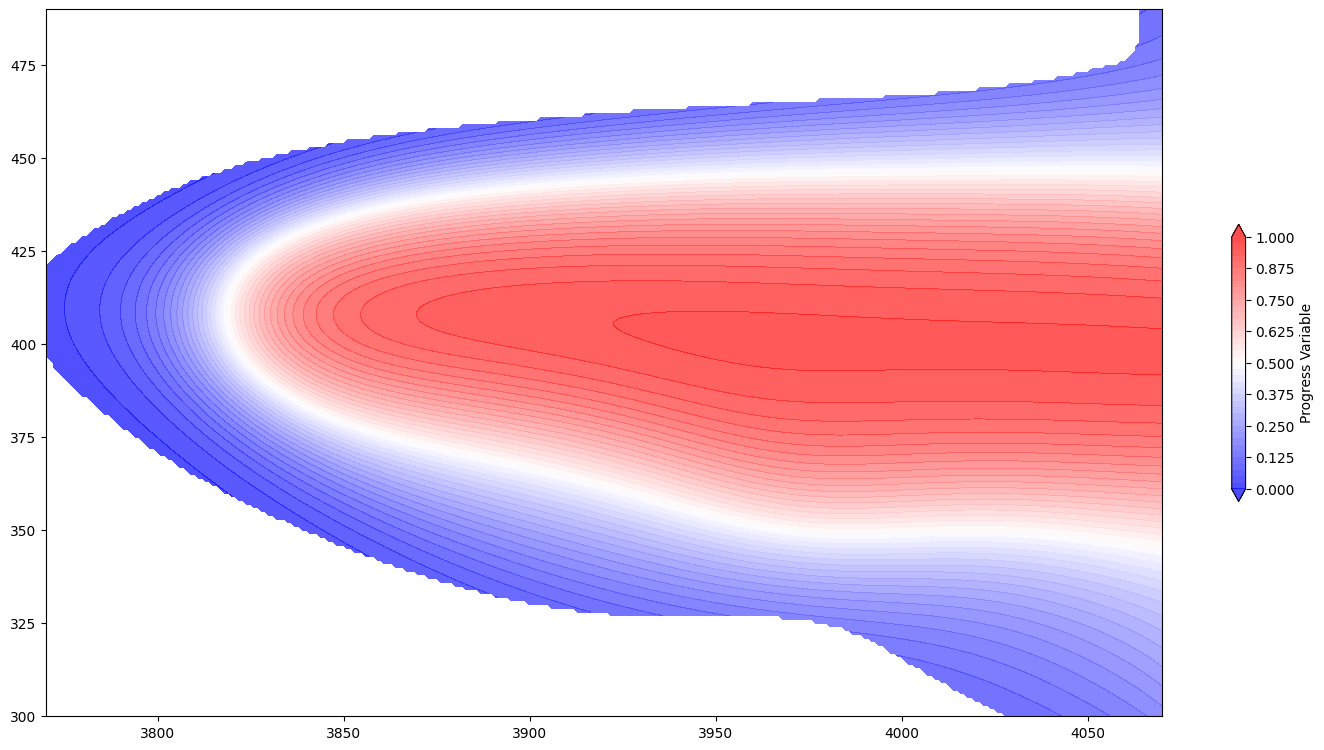

In [47]:
df2 = df[(df['x_grid']>=3770) & (df['x_grid']<=4070) &(df['y_grid']>=300) &(df['y_grid']<=490) &(df['z_grid']==1)]
#df2= df.copy()
divu_grid=df2.pivot_table(
    index='y_grid',
    columns='x_grid',
    values='c',
    aggfunc='median',
)
vmin=0
vmax=1
levels=np.linspace(vmin,vmax,41,)

X=divu_grid.columns.values
Y=divu_grid.index.values
Z=divu_grid.values
fig,ax = plt.subplots(figsize=(18,12))
ax.set_aspect('equal')
cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 ,extend='both')
cbar =plt.colorbar(cf,shrink=0.3,ax=ax,label='Progress Variable')
plt.savefig('plt73800_c_slice_z=1.png')

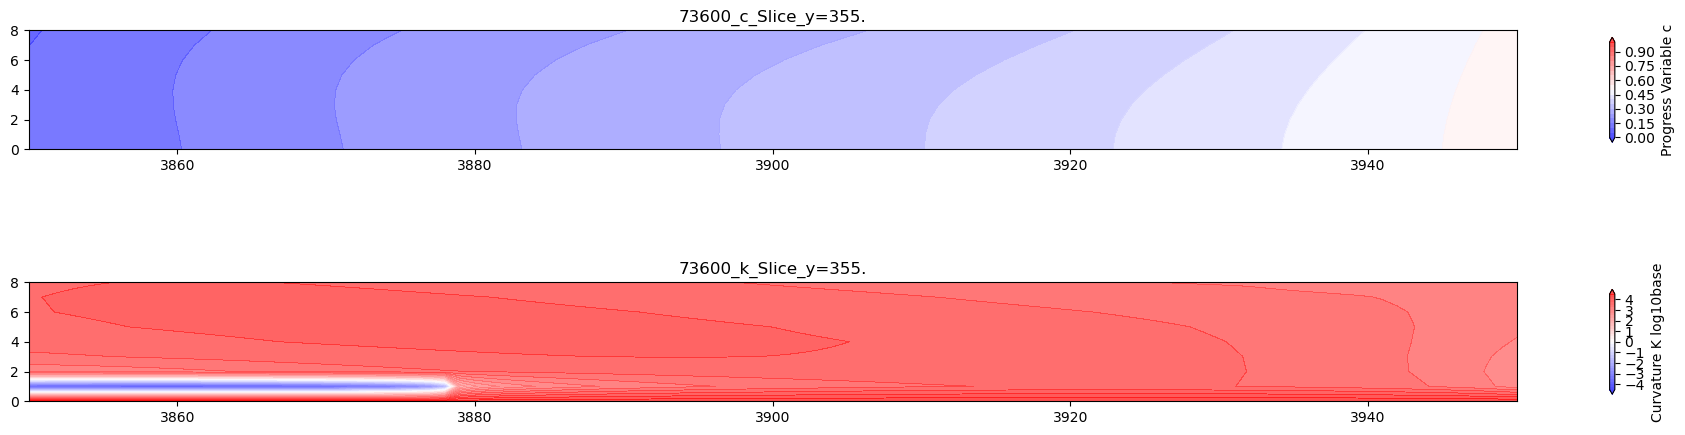

In [51]:
yslice = 355
xleft = 3850
xright= 3950
pltname = 73600
df_slice = df[(df['y_grid']==yslice ) & (df['z_grid']<=8)  & (df['x_grid']>=xleft) & (df['x_grid']<=xright)  ]

slicec_grid=df_slice.pivot_table(
    index='z_grid',
    columns='x_grid',
    values='c',
    aggfunc='median',
)

vmin=0
vmax=1
levels1=np.linspace(0,1,21,)
X=slicec_grid.columns.values
Y=slicec_grid.index.values
Zc=slicec_grid.values

fig,ax = plt.subplots(2,1,figsize=(24,6))
ax[0].set_aspect('equal')
ax[0].set_title(f'{pltname}_c_Slice_y={yslice}.')


cf=ax[0].contourf(X,Y,Zc,levels=levels1,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7,extend='both' )
cbar =plt.colorbar(cf,shrink=0.5,ax=ax[0],label='Progress Variable c')

vkmin=-4.5
vkmax= 4.5
levels2=np.linspace(vkmin,vkmax,37)
slicek_grid=df_slice.pivot_table(
    index='z_grid',
    columns='x_grid',
    values='pn_log_k',
    aggfunc='median',
)
X=slicek_grid.columns.values
Y=slicek_grid.index.values
Zk=slicek_grid.values

cf1=ax[1].contourf(X,Y,Zk,levels=levels2,cmap='bwr',vmin=vkmin,vmax=vkmax, alpha=0.7,extend= 'both' )
ax[1].set_aspect('equal')
ax[1].set_title(f'{pltname}_k_Slice_y={yslice}.')

cbar2 =plt.colorbar(cf1,shrink=0.5,ax=ax[1],label='Curvature K log10base')
colors = [
    "#f0f0f0",  # 1
    "#d9d9d9",  # 2
    "#bdbdbd",  # 3
    "#969696",  # 4
    "#737373",  # 5
    "#525252",  # 6
    "#404040",  # 7
    "#252525",  # 8
    "#000000",  # 9
]


#plt.savefig(f'{pltname}_ck_slice_y={yslice}.png',dpi=300)

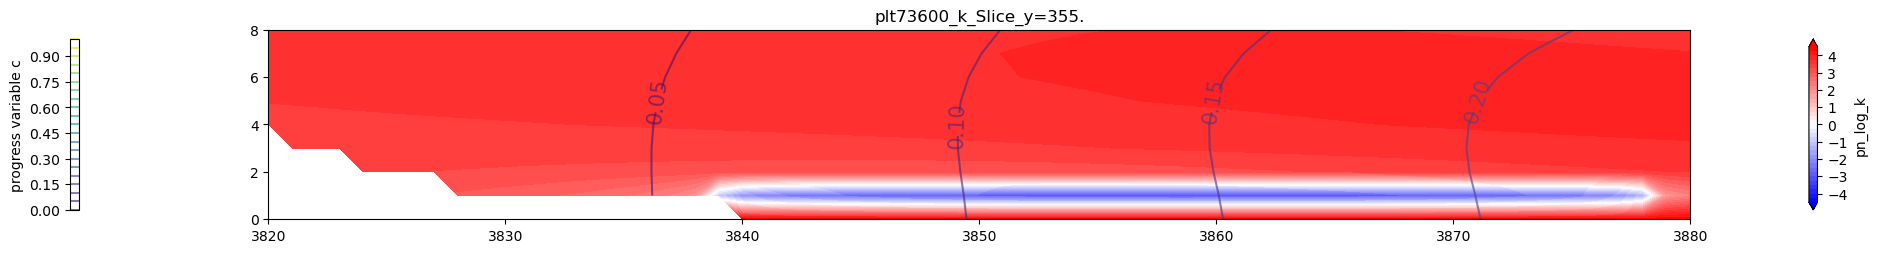

In [71]:
yslice = 355
xleft = 3820
xright= 3880
pltname = 'plt73600'
df_slice = df[(df['y_grid']==yslice ) & (df['z_grid']<=8)  & (df['x_grid']>=xleft) & (df['x_grid']<=xright)  ]

vkmin=-4.5
vkmax= 4.5
levels2=np.linspace(vkmin,vkmax,37)
fig,ax = plt.subplots(1,1,figsize=(24,6))

slicek_grid=df_slice.pivot_table(
    index='z_grid',
    columns='x_grid',
    values='pn_log_k',
    aggfunc='median',
)
X=slicek_grid.columns.values
Y=slicek_grid.index.values
Zk=slicek_grid.values



cf1=ax.contourf(X,Y,Zk,levels=levels2,cmap='bwr',vmin=vkmin,vmax=vkmax,extend= 'both',alpha=1.0 )
slicec_grid=df_slice.pivot_table(
    index='z_grid',
    columns='x_grid',
    values='c',
    aggfunc='median',
)

vmin=0
vmax=1
levels1=np.linspace(0,1,21,)
X=slicec_grid.columns.values
Y=slicec_grid.index.values
Zc=slicec_grid.values
cs =ax.contour(X,Y,Zc,levels=levels1,cmap='viridis',vmin=vmin,vmax=vmax,alpha=0.6)
ax.clabel(cs,inline=True,fontsize=15,fmt='%.2f')
cbar =plt.colorbar(cf1,shrink=0.3,ax=ax,label='pn_log_k',location='right')
cbar2 =plt.colorbar(cs,shrink=0.3,ax=ax,label='progress variable c',location='left')
ax.set_aspect('equal')
ax.set_title(f'{pltname}_k_Slice_y={yslice}.')

"""
colors = [
    "#f0f0f0",  # 1
    "#d9d9d9",  # 2
    "#bdbdbd",  # 3
    "#969696",  # 4
    "#737373",  # 5
    "#525252",  # 6
    "#404040",  # 7
    "#252525",  # 8
    "#000000",  # 9
]

for i in range(1,5,1):
    curr_c = 0.05*i+0.0
    df_temp = df_slice[df_slice['c']>=curr_c]
    df_minx = df_minx = (df_temp.groupby('z_grid', as_index=False)['x_grid'].min().rename(columns={'x_grid': 'min_x_grid'}))
    ax.plot(df_minx['min_x_grid'],df_minx['z_grid'],label=f'c={round(curr_c,2)}', color=colors[i-1])
cbar = fig.colorbar(
    cf1,
    ax=ax,
    pad=0.02,
    shrink=0.4,
    label='Curvature K log10base'
)

# legend放最外面
ax.legend(
    loc='center right',
    bbox_to_anchor=(-0.08, 0.5),   # 左边图外
    title='Progress Variable',
    frameon=True,
    fontsize=10
)
"""
plt.tight_layout()

plt.savefig(f'{pltname}_ck_slice_combined_y={yslice}.png',dpi=300)

In [99]:
df[(df['z_grid'].isin([1,2,3])) &(df['x_grid']>=3850)&(df['x_grid']<=3870) &(df['y_grid']==355)][['k','divnx','divny','divnz','z_grid']].head(20)

,k,divnx,divny,divnz,z_grid
217253,-786.550392,326.047438,-123.841025,-988.756805,1
217254,1173.445983,328.652071,-124.679607,969.473520,2
217255,2808.812321,330.147315,-142.254201,2620.919207,3
220757,-835.033326,328.714289,-126.084735,-1037.662880,1
220758,1186.656840,331.445503,-127.114369,982.325706,2
220759,2862.823990,333.357271,-144.775039,2674.241758,3
224273,-878.487446,331.111698,-128.220304,-1081.378839,1
224274,1204.507437,333.900457,-129.555647,1000.162627,2
224275,2920.555419,336.233981,-147.267304,2731.588742,3
227809,-916.586295,333.164434,-130.283271,-1119.467457,1


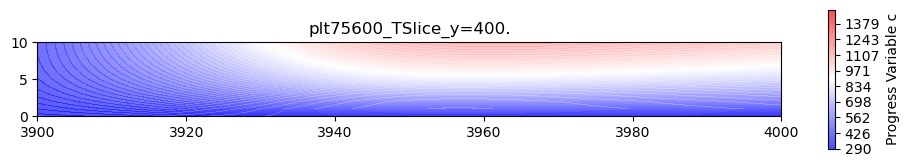

In [52]:
df_sliceT = df[(df['y_grid']==yslice ) & (df['z_grid']<=10)  & (df['x_grid']>=xleft) & (df['x_grid']<=xright)  ]
Tslice_grid=df_sliceT.pivot_table(
    index='z_grid',
    columns='x_grid',
    values='T',
    aggfunc='median',
)

vmin=290
vmax=1500
levels=np.linspace(vmin,vmax,81,)
X=Tslice_grid.columns.values
Y=Tslice_grid.index.values
Z=Tslice_grid.values
fig,ax = plt.subplots(figsize=(12,9))
ax.set_aspect('equal')
ax.set_title(f'plt75600_TSlice_y={yslice}.')

cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 )
cbar =plt.colorbar(cf,shrink=0.2,ax=ax,label='Progress Variable c')
plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt75600_T_slice_y={yslice}.png',dpi=300)

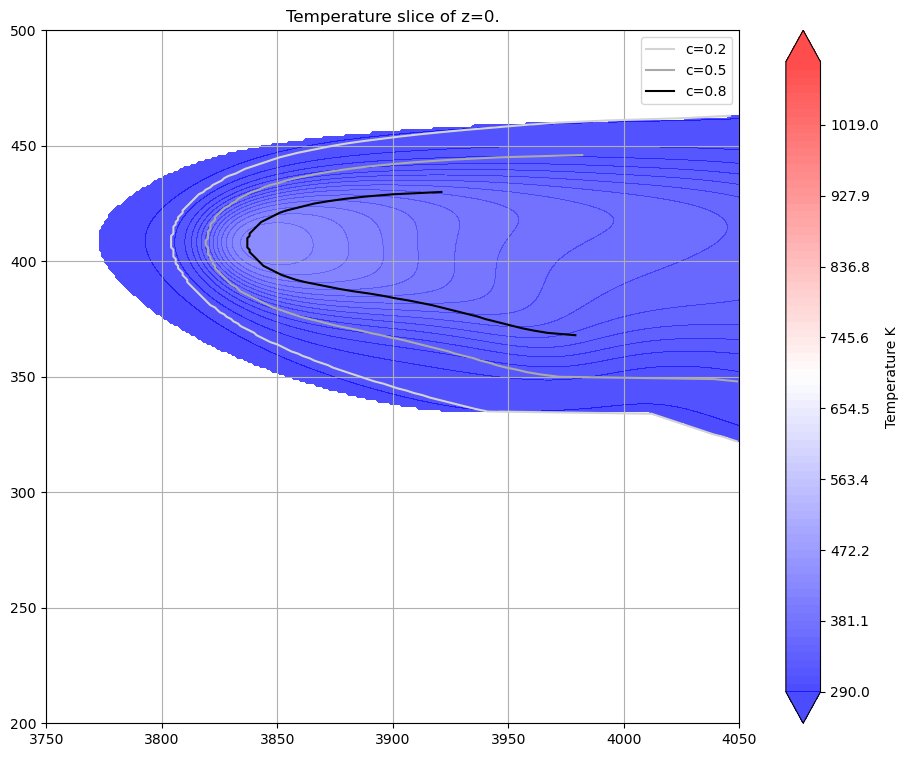

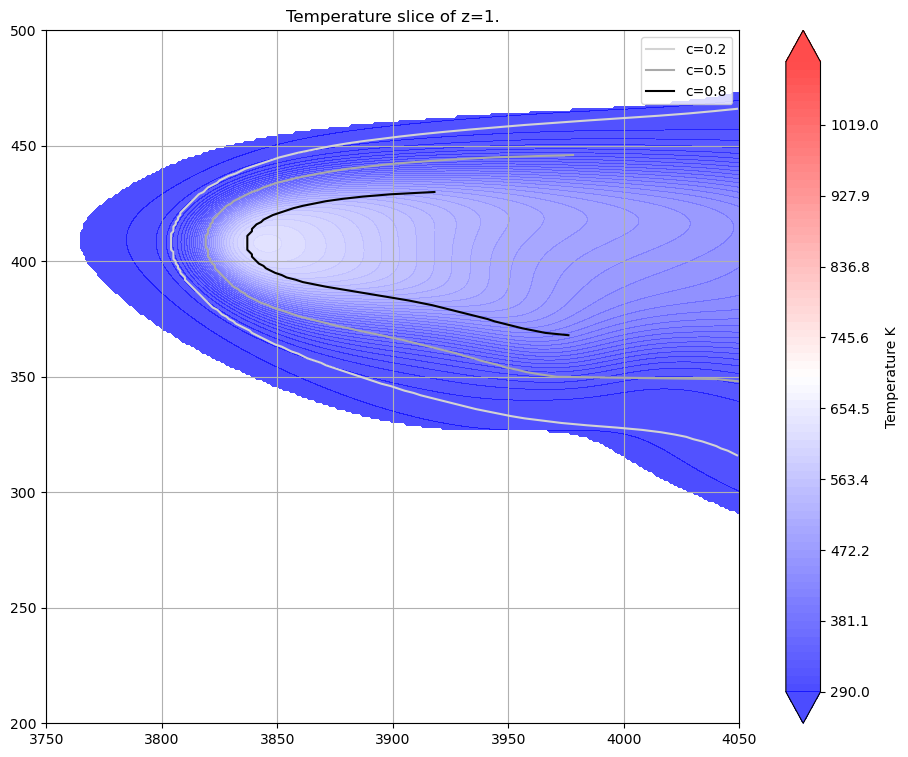

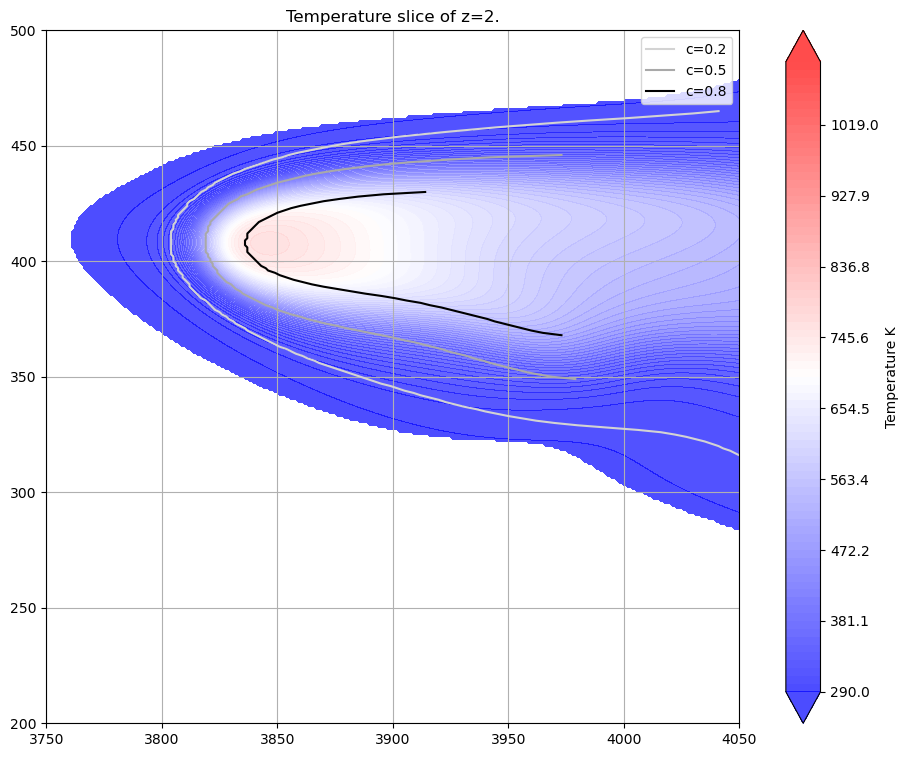

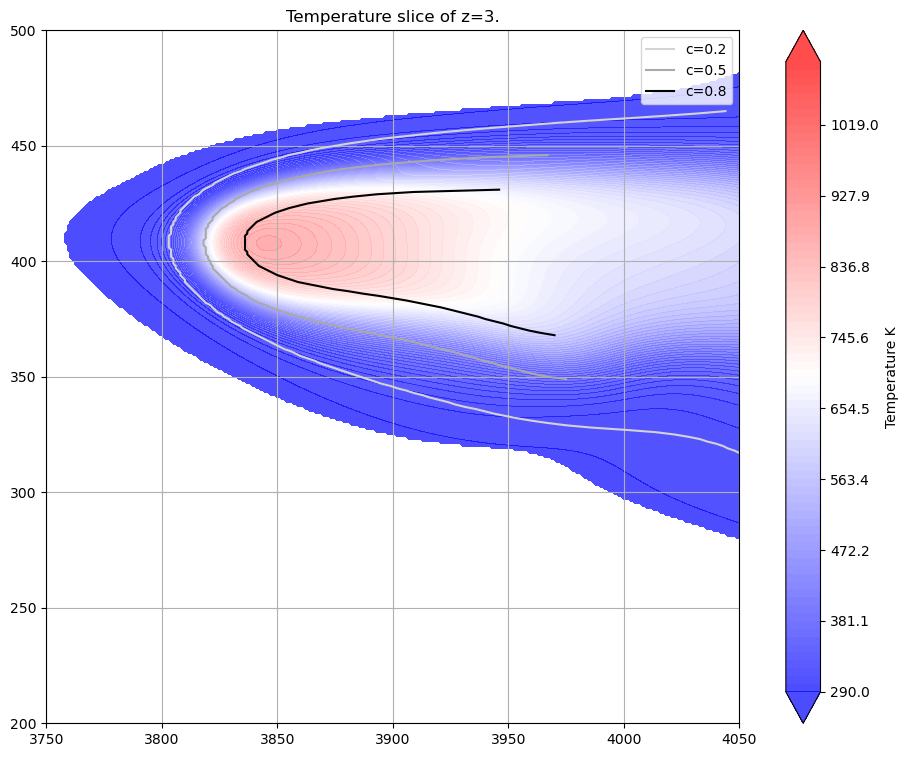

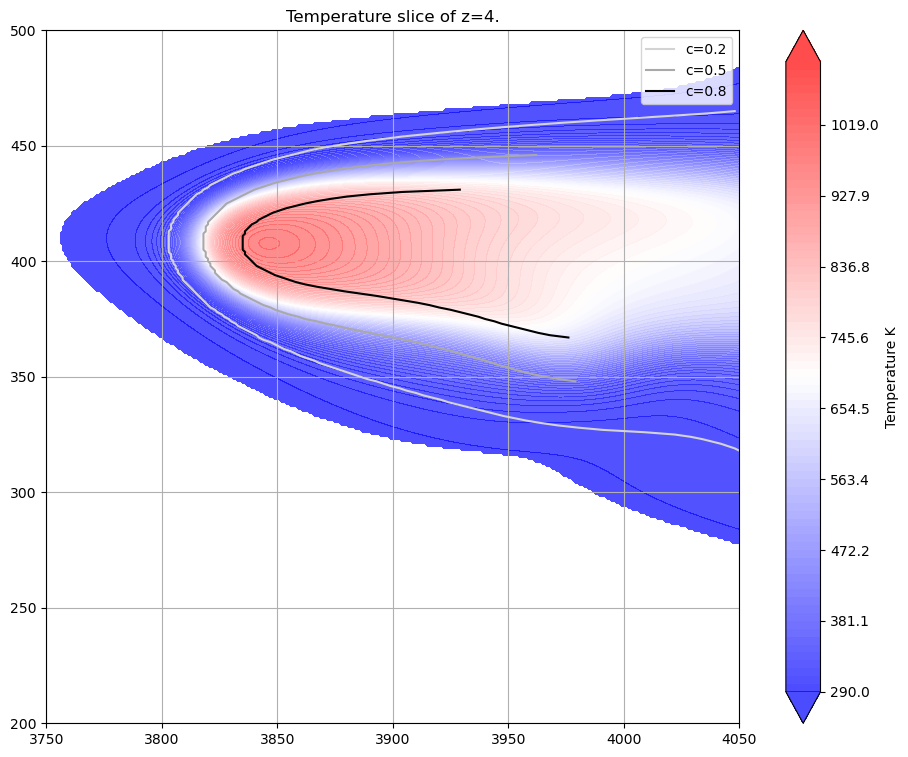

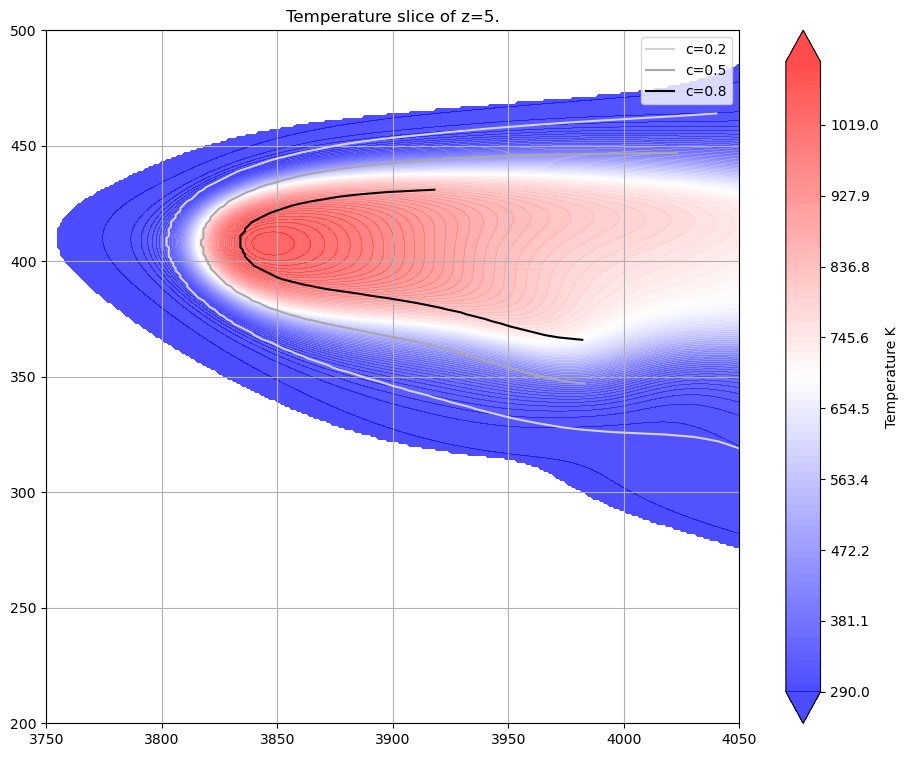

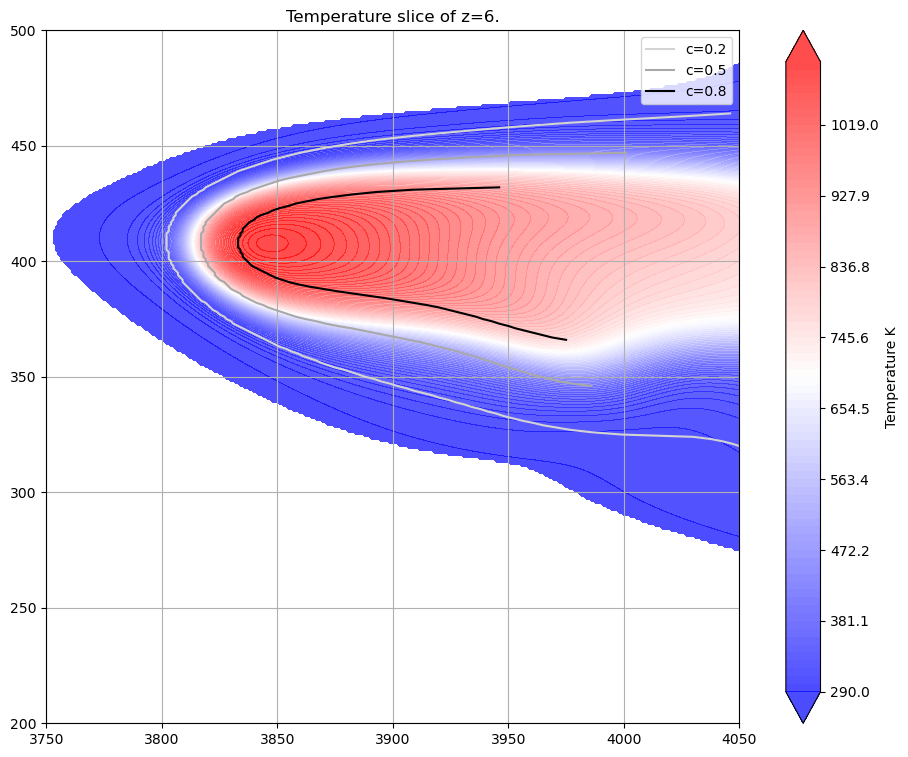

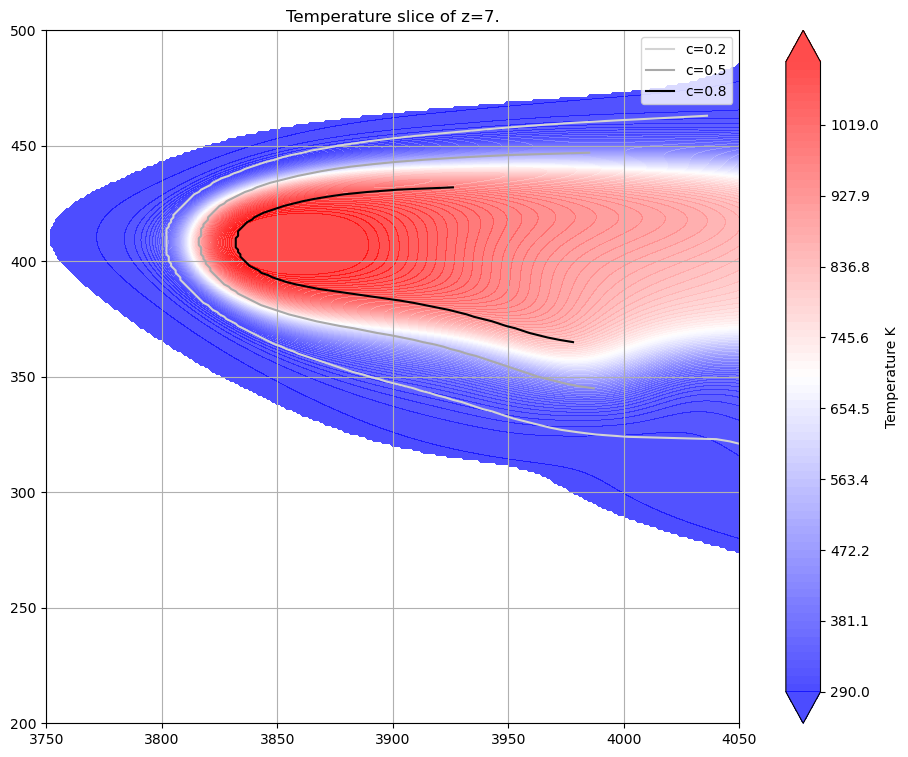

In [11]:
for i in range(0,8):
    df_s2= df[(df['z_grid']==i) & (df['x_grid']<=4050) & (df['x_grid']>=3750)& (df['y_grid']<=500)&(df['y_grid']>=200)  ].copy()
    df_sr_vc02 = df_s2[df_s2['c']>=0.2]
    df_sr_vc05 = df_s2[df_s2['c']>=0.5]
    df_sr_vc08 = df_s2[df_s2['c']>=0.8]
    df_sr_vc02minx   = df_sr_vc02.loc[df_sr_vc02.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc05minx   = df_sr_vc05.loc[df_sr_vc05.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc08minx   = df_sr_vc08.loc[df_sr_vc08.groupby('y_grid')['x_grid'].idxmin()].copy()
    slice_grid=df_s2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='T',
        aggfunc='median',
    )
    
    vmin=290
    vmax=1100
    levels=np.linspace(vmin,vmax,81,)
    X=slice_grid.columns.values
    Y=slice_grid.index.values
    Z=slice_grid.values
    fig,ax = plt.subplots(figsize=(12,9))
    ax.set_aspect('equal')
    
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 ,extend='both')
    cbar =plt.colorbar(cf,ax=ax,label='Temperature K')
    ax.set_title(f'Temperature slice of z={i}.')
    ax.plot(df_sr_vc02minx['x_grid'],df_sr_vc02minx['y_grid'], label='c=0.2',color ='lightgray' )
    ax.plot(df_sr_vc05minx['x_grid'],df_sr_vc05minx['y_grid'], label='c=0.5',color ='darkgray' )
    ax.plot(df_sr_vc08minx['x_grid'],df_sr_vc08minx['y_grid'], label='c=0.8',color ='black' )
    ax.legend()
    ax.set_ylim(200,500)
    ax.set_xlim(3750,4050)
    ax.grid()
    #plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt75600_Hrz_TempSlice_z={i}.png',dpi=600)
    

In [94]:
df[(df['x_grid']>=3915) & (df['x_grid']<=3925) & (df['y_grid']>=270) & (df['y_grid']<=280) & (df['z_grid']==1) ]

,x_grid,y_grid,z_grid,T,Q,P,rho,cp,Y(H2),lambda,k,Sd,gradT,flx,c
584613,3915,270,1,305.536814,125415.542744,101324.897149,0.993171,1182.803793,0.009351,0.040584,-15529.669852,0.425739,280403.873725,118457.578055,0.232362
584646,3915,271,1,305.318905,122019.611913,101324.897865,0.993755,1182.924150,0.009363,0.040574,-15354.291733,0.423839,272091.552014,114499.662910,0.231375
584679,3915,272,1,305.127679,119006.088078,101324.897906,0.994250,1183.046809,0.009375,0.040568,-15175.412500,0.421570,264764.178191,110874.213491,0.230329
584712,3915,273,1,304.962951,116372.642360,101324.897877,0.994655,1183.176908,0.009389,0.040564,-14999.477210,0.418971,258418.484645,107592.843263,0.229245
584745,3915,274,1,304.824006,114110.926741,101324.897422,0.994969,1183.318476,0.009402,0.040564,-14831.098306,0.416093,253030.211331,104658.073236,0.228140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664361,3925,276,1,306.105331,134033.452411,101324.854897,0.992649,1182.078156,0.009068,0.040332,-13976.202101,0.402314,298464.950516,119080.579216,0.255582
664390,3925,277,1,306.060308,132507.073348,101324.853126,0.992613,1182.286467,0.009083,0.040344,-13876.329367,0.399461,296619.866241,117500.704988,0.254310
664419,3925,278,1,306.039612,131393.082756,101324.856523,0.992489,1182.516950,0.009098,0.040357,-13793.257807,0.396484,295668.997972,116236.319098,0.253129
664446,3925,279,1,306.039620,130664.611265,101324.852870,0.992290,1182.767770,0.009111,0.040370,-13730.959225,0.393936,295471.741546,115389.166099,0.252049


In [135]:
df['Sd'].min()

-7.94847695979012

In [137]:
df

,x_grid,y_grid,z_grid,T,Q,P,rho,cp,Y(H2),lambda,k,Sd,gradT,flx,c
77745,3822,360,1,306.649441,9.280172e+04,101324.902968,0.976644,1201.654441,0.009743,0.041050,-14558.618624,0.436815,3.255987e+05,1.388273e+05,0.799877
77788,3822,361,1,306.311721,8.920618e+04,101324.902866,0.978594,1200.209461,0.009745,0.041023,-14493.373368,0.435726,3.128283e+05,1.333153e+05,0.799982
80512,3823,357,1,307.629572,1.035424e+05,101324.907687,0.971284,1205.455798,0.009730,0.041123,-12892.788293,0.441002,3.628543e+05,1.553384e+05,0.798802
80513,3823,357,2,313.653940,9.468160e+04,101324.880726,0.953148,1205.065874,0.009740,0.041788,-11873.225342,-0.155626,3.408550e+05,-5.063926e+04,0.799602
80555,3823,358,1,307.432089,1.016398e+05,101324.904827,0.972564,1204.426368,0.009718,0.041093,-13760.712724,0.439219,3.551688e+05,1.516324e+05,0.797829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4507511,4115,839,7,1286.502868,3.844771e+09,101325.157029,0.242200,1359.511284,0.002529,0.124678,-499.890992,1.039693,2.495900e+06,-2.199551e+06,0.207644
4507535,4115,840,7,1288.362588,3.836680e+09,101325.159456,0.241824,1359.682144,0.002515,0.124848,-521.999750,1.039438,2.474997e+06,-2.199631e+06,0.206453
4507559,4115,841,7,1290.495791,3.825415e+09,101325.159639,0.241398,1359.844012,0.002497,0.125035,-544.640996,1.038538,2.450637e+06,-2.198750e+06,0.204987
4507583,4115,842,7,1292.887403,3.811100e+09,101325.164871,0.240928,1359.994564,0.002476,0.125241,-568.051477,1.036971,2.422998e+06,-2.196940e+06,0.203260


In [112]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd

d1 = '/home/u0890475/Downloads/amr4_curv_combtest/plt73800_curvature.csv'
df = pd.read_csv(d1)


In [140]:
def plot_general(df,y='x_grid',x='y_grid',v='',vmin=0,vmax=100,fname=''):
        
    Tslice_grid=df.pivot_table(
        index=x,
        columns=y,
        values=v,
        aggfunc='median',
    )
    
    
    levels=np.linspace(vmin,vmax,81,)
    X=Tslice_grid.columns.values
    Y=Tslice_grid.index.values
    Z=Tslice_grid.values
    fig,ax = plt.subplots(figsize=(12,9))
    ax.set_aspect('equal')
    fullname = f'{fname}_{v}Slice.'
    ax.set_title(fullname)
    
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7,extend='both' )
    cbar =plt.colorbar(cf,shrink=0.2,ax=ax,label=v)
    plt.savefig(f'{fullname}.png')
    plt.show()

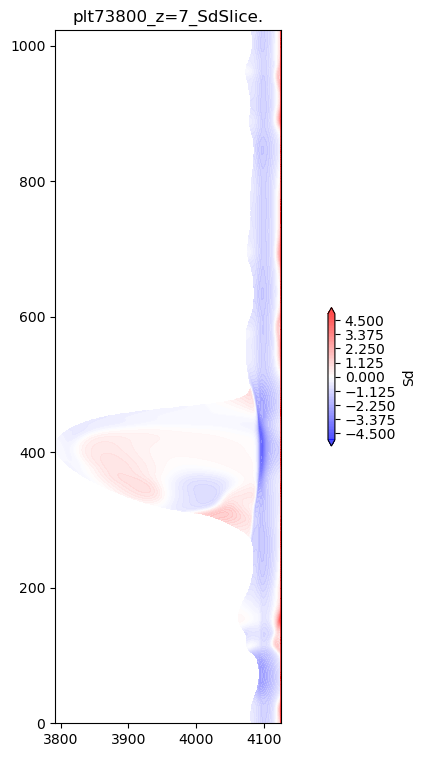

In [160]:
df['c'] = 1- df['Y(H2)']/0.012181
df1 = df[(df['z_grid'] ==7)]
df1 = df1[(df1['c']>=0.1)]
plot_general(df1,v='Sd',vmin=-5,vmax=5,fname='plt73800_z=7')

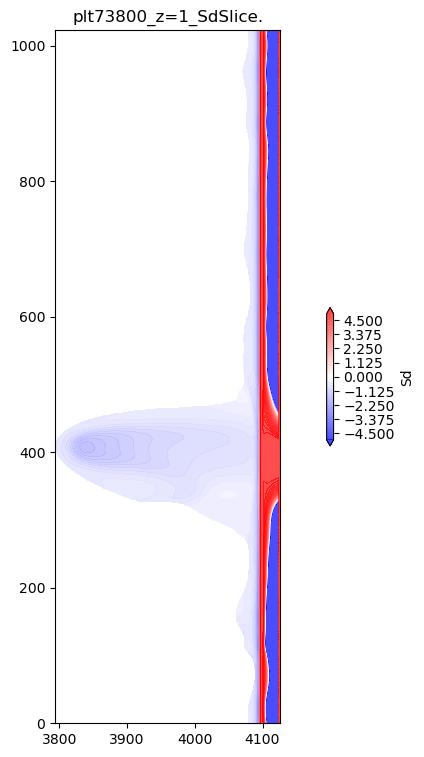

In [1]:
import pyvista as pv
pv.set_jupyter_backend('trame')
mesh = pv.read('/home/u0890475/Downloads/plt73800_temp_1000.vtk')

In [ ]:
p=pv.Plotter(notebook=True)
p.add_mesh(mesh,scalars='T')
p.show()